# Proiect Machine Learning – Regresie

## Analiza performantei academice a studentilor pe baza factorilor educationali, sociali si personali

**Student:** Maria Timoc
**Dataset:** Student Performance Factors
**Target:** Exam_Score

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
df = pd.read_csv("Datasets/StudentPerformanceFactors.csv")

df = df.sample(n=2000, random_state=42)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
743,20,71,Medium,Low,No,7,87,High,Yes,1,Medium,Medium,Public,Negative,5,No,High School,Near,Male,65
5551,22,71,Medium,Low,Yes,7,98,Low,Yes,2,Low,High,Public,Neutral,2,No,High School,Moderate,Female,65
3442,21,91,High,Medium,Yes,6,53,High,Yes,1,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Female,71
6571,12,91,Medium,Low,Yes,8,81,Low,Yes,0,Low,Low,Public,Positive,4,No,High School,Moderate,Male,64
4204,21,63,Low,High,Yes,8,95,Medium,Yes,2,High,Medium,Public,Neutral,5,No,High School,Near,Male,66


## 4.1 Definirea problemei

Scopul acestei probleme de regresie este prezicerea scorului final obtinut de un student la examen pe baza unor factori educationali, personali si sociali.

Variabila tinta este Exam_Score.

Caracteristicile de intrare includ factori precum:
- Hours_Studied
- Attendance
- Sleep_Hours
- Previous_Scores
- Tutoring_Sessions
- Physical_Activity
- Parental_Involvement
- Access_to_Resources

Problema este relevanta deoarece performanta academica poate fi influentata de numerosi factori, iar un model de machine learning poate ajuta la identificarea relatiilor dintre acestia si rezultatul final.

Am ales aceasta problema deoarece este practica, usor de inteles si permite o analiza clara a factorilor care influenteaza succesul academic, folosind modele de regresie, metrici si grafice relevante.

## 4.2 Analiza exploratorie a datelor si pregatirea lor

In aceasta etapa se urmareste intelegerea structurii dataset-ului, verificarea calitatii datelor si identificarea relatiilor dintre variabile.

Vor fi analizate:
- dimensiunea dataset-ului
- tipurile de date
- valorile lipsa
- eventualele anomalii
- distributia variabilelor numerice
- relatia dintre caracteristici si Exam_Score

Scopul este pregatirea corecta a datelor pentru modelele de machine learning, astfel incat acestea sa poata invata cat mai eficient din informatiile disponibile.

Prin analiza exploratorie se pot observa tipare importante, variabile influente si eventuale probleme care necesita corectare inainte de antrenarea modelelor.

In [103]:
df.shape

(2000, 20)

In [104]:
df.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, 743 to 2850
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               2000 non-null   int64
 1   Attendance                  2000 non-null   int64
 2   Parental_Involvement        2000 non-null   str  
 3   Access_to_Resources         2000 non-null   str  
 4   Extracurricular_Activities  2000 non-null   str  
 5   Sleep_Hours                 2000 non-null   int64
 6   Previous_Scores             2000 non-null   int64
 7   Motivation_Level            2000 non-null   str  
 8   Internet_Access             2000 non-null   str  
 9   Tutoring_Sessions           2000 non-null   int64
 10  Family_Income               2000 non-null   str  
 11  Teacher_Quality             1974 non-null   str  
 12  School_Type                 2000 non-null   str  
 13  Peer_Influence              2000 non-null   str  
 14  Physical_Activity     

In [105]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,20.011000,79.97200,7.024500,74.999500,1.472000,2.95650,67.231000
std,6.020216,11.51058,1.480877,14.263317,1.212003,1.02963,3.711135
min,2.000000,60.00000,4.000000,50.000000,0.000000,0.00000,55.000000
25%,16.000000,70.00000,6.000000,63.000000,1.000000,2.00000,65.000000
50%,20.000000,79.00000,7.000000,75.000000,1.000000,3.00000,67.000000
75%,24.000000,90.00000,8.000000,87.000000,2.000000,4.00000,70.000000
max,44.000000,100.00000,10.000000,100.000000,7.000000,6.00000,98.000000


In [106]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               26
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      30
Distance_from_Home            21
Gender                         0
Exam_Score                     0
dtype: int64

In [107]:
df.duplicated().sum()

np.int64(0)

In [108]:
df["Exam_Score"].describe()

count    2000.000000
mean       67.231000
std         3.711135
min        55.000000
25%        65.000000
50%        67.000000
75%        70.000000
max        98.000000
Name: Exam_Score, dtype: float64

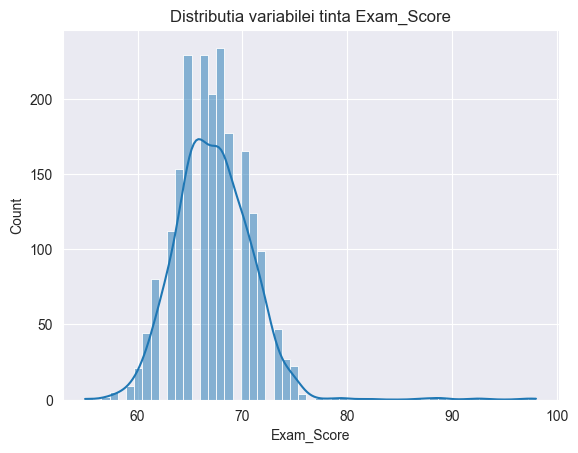

In [109]:
sns.histplot(data=df, x="Exam_Score", kde=True)
plt.title("Distributia variabilei tinta Exam_Score")
plt.show()

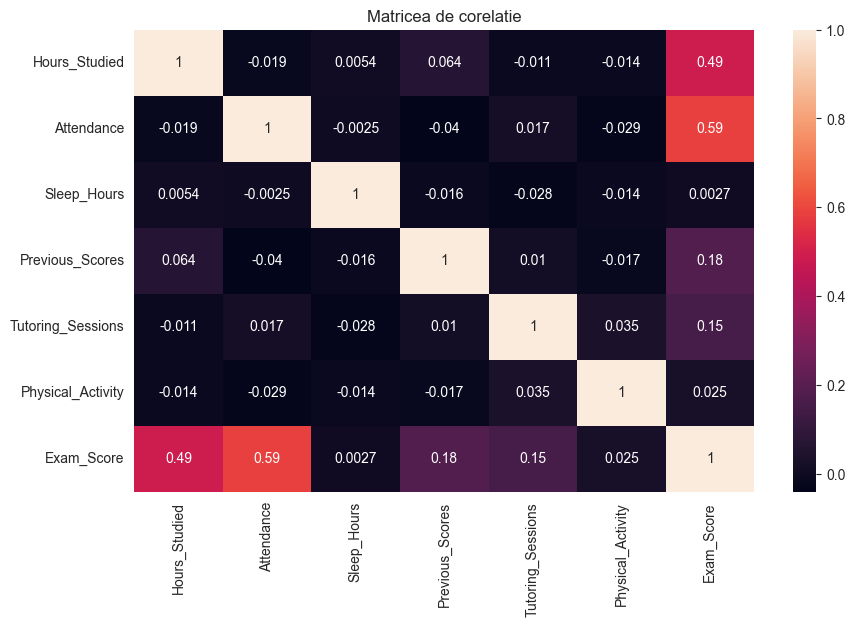

In [110]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Matricea de corelatie")
plt.show()

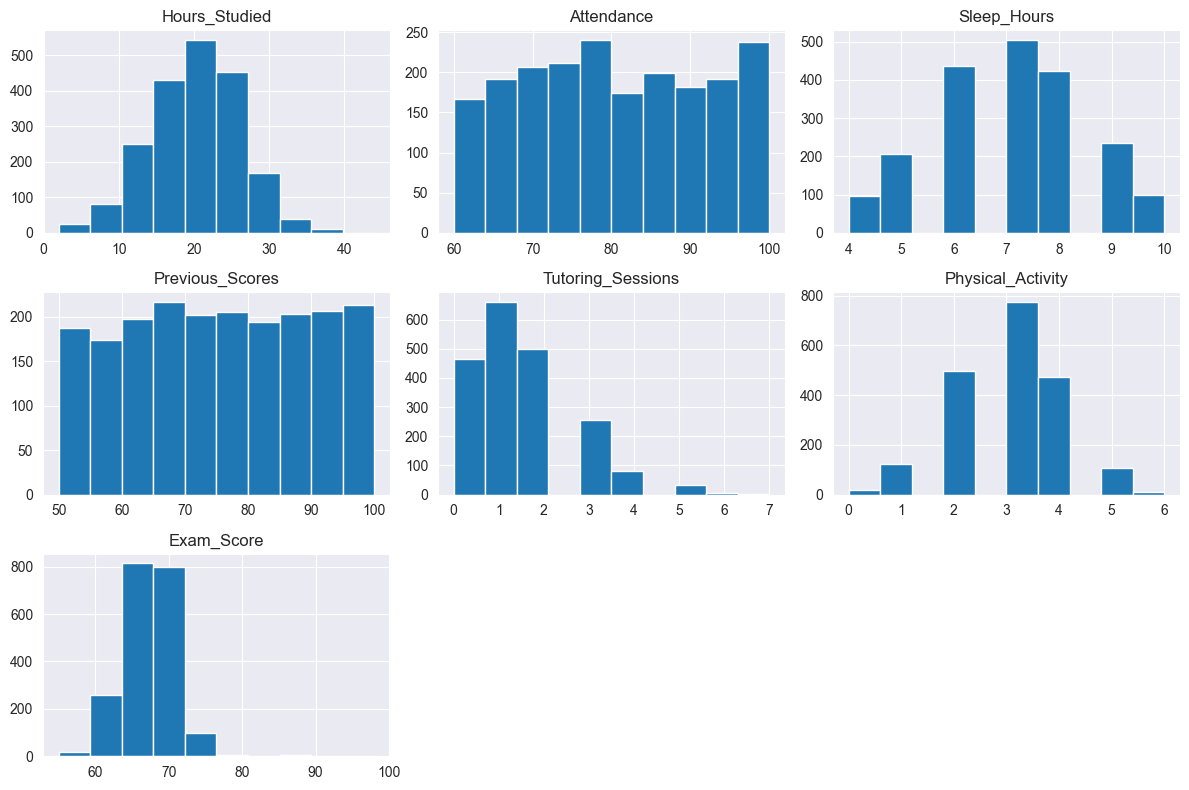

In [111]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

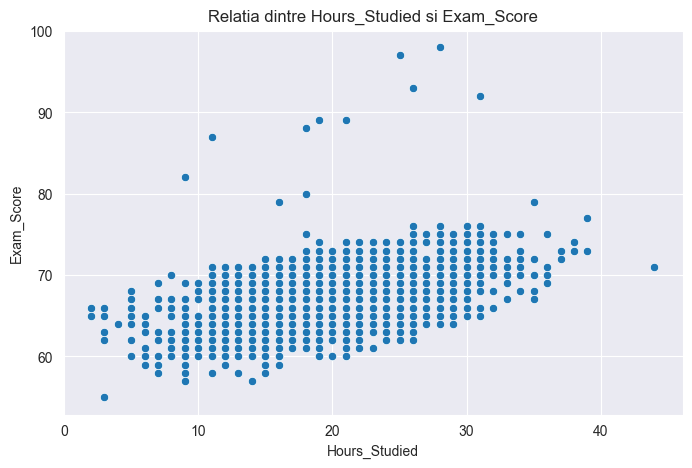

In [112]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Hours_Studied", y="Exam_Score")
plt.title("Relatia dintre Hours_Studied si Exam_Score")
plt.show()

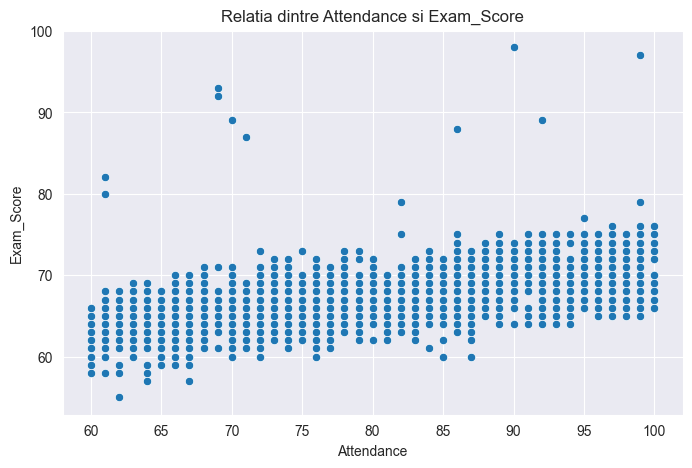

In [113]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Attendance", y="Exam_Score")
plt.title("Relatia dintre Attendance si Exam_Score")
plt.show()

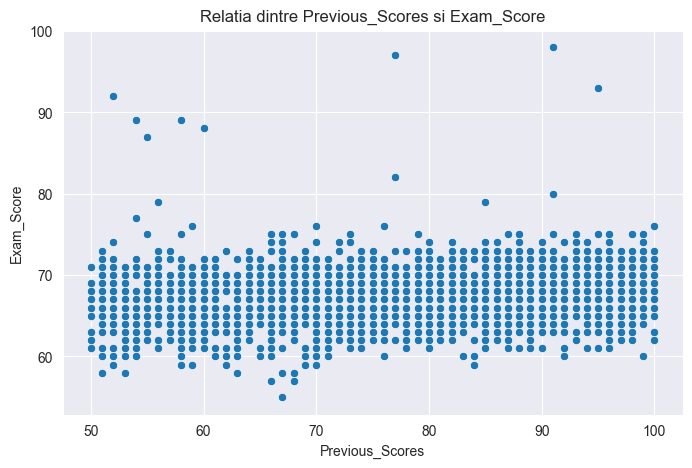

In [114]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Previous_Scores", y="Exam_Score")
plt.title("Relatia dintre Previous_Scores si Exam_Score")
plt.show()

## 4.2 Analiza exploratorie a datelor

### Observatii:

Dataset-ul contine 2000 observatii si 20 variabile, fara valori lipsa sau duplicate, ceea ce indica un set de date curat si potrivit pentru analiza.

Variabila tinta Exam_Score are o distributie apropiata de una normala, majoritatea valorilor fiind concentrate in jurul intervalului 65–70, cu cateva valori extreme mai ridicate.

Matricea de corelatie arata ca cele mai importante relatii cu Exam_Score sunt:

- Attendance (~0.59) – cea mai puternica influenta pozitiva
- Hours_Studied (~0.49) – influenta pozitiva moderata
- Previous_Scores (~0.18) – influenta mai redusa, dar existenta

Sleep_Hours si Physical_Activity prezinta corelatii foarte slabe cu scorul final, sugerand o influenta directa mai mica in acest dataset.

Histogramele indica distributii rezonabile pentru variabilele numerice, fara dezechilibre majore.

Graficele scatter confirma faptul ca:

- Cresterea numarului de ore studiate este asociata, in general, cu scoruri mai mari
- Prezenta mai buna la cursuri are o relatie clara cu performanta academica
- Scorurile anterioare au o influenta mai redusa decat era de asteptat

In ansamblu, analiza sugereaza ca factorii educationali directi (studiu si prezenta) influenteaza mai mult performanta decat factorii de stil de viata.

Aceste observatii confirma relevanta problemei si ofera o baza buna pentru etapa urmatoare de antrenare si comparare a modelelor de regresie.

## 4.3 Antrenarea si compararea modelelor de baza

In aceasta etapa am antrenat si comparat mai multi algoritmi de regresie pentru a determina care dintre ei poate prezice cel mai bine scorul final al studentilor (Exam_Score) pe baza variabilelor disponibile in dataset.

Conform cerintei proiectului, datele au fost impartite astfel:

- 75% pentru antrenare
- 25% pentru testare si validare

Scopul acestei etape este compararea performantei mai multor algoritmi folosind aceleasi date si aceleasi criterii de evaluare.

### Algoritmi folositi:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Support Vector Regressor (SVR)
- K-Nearest Neighbors Regressor (KNN)
- Gaussian Process Regressor
- Xtreme Gradient Boost Regressor (XGBoost)
- Categorical Boost Regressor (CatBoost)
- Explainable Boosting Regressor (EBM)

### Pasii realizati:

Pentru fiecare algoritm:

1. Am antrenat modelul pe setul de training
2. Am realizat predictii pe setul de test
3. Am calculat metricile de performanta:
   - MSE
   - MAE
   - RMSE
   - R2 Score
4. Am comparat rezultatele intr-un tabel comparativ Markdown
5. Am selectat primele 5 modele pe baza performantei generale

### Metricile utilizate:

#### MSE (Mean Squared Error)
Masoara media patratelor erorilor dintre valorile reale si cele prezise.

#### MAE (Mean Absolute Error)
Arata eroarea medie absoluta a predictiilor.

#### RMSE (Root Mean Squared Error)
Reflecta eroarea medie intr-o forma mai usor de interpretat, avand aceeasi unitate ca variabila tinta.

#### R2 Score
Indica procentul din variatia scorului final explicat de model.

### De ce folosesc mai multi algoritmi:

Fiecare model are caracteristici diferite:

#### Linear Regression
- simplu
- interpretabil
- bun ca punct de referinta

#### Decision Tree Regressor
- usor de inteles
- surprinde relatii non-liniare

#### Random Forest Regressor
- mai stabil
- reduce overfitting-ul

#### SVR
- performant pentru relatii complexe
- eficient dupa scalare

#### KNN Regressor
- bazat pe similaritatea dintre observatii

#### Gaussian Process Regressor
- flexibil
- poate modela relatii complexe

#### XGBoost Regressor
- foarte performant
- optimizeaza iterativ erorile

#### CatBoost Regressor
- performant
- eficient pentru date diverse

#### Explainable Boosting Regressor (EBM)
- combina performanta cu interpretabilitatea

### Scop final:

La final, toate modelele sunt comparate folosind aceleasi metrici pentru a identifica algoritmii cu cele mai bune rezultate.

Primele 5 modele vor fi selectate pentru etapele urmatoare de optimizare, analiza curbelor de invatare si interpretare SHAP.


In [115]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [116]:
df_encoded = df.copy()

label_encoders = {}

for column in df_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

X = df_encoded.drop("Exam_Score", axis=1)
y = df_encoded["Exam_Score"]

C:\Users\Maria\AppData\Local\Temp\ipykernel_8116\3369268993.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_encoded.select_dtypes(include="object").columns:


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [118]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [119]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [120]:
models = [
    ("Linear Regression", LinearRegression(), X_train_scaled, X_test_scaled),
    ("Decision Tree Regressor", DecisionTreeRegressor(random_state=42), X_train, X_test),
    ("Random Forest Regressor", RandomForestRegressor(random_state=42), X_train, X_test),
    ("SVR", SVR(), X_train_scaled, X_test_scaled),
    ("KNN Regressor", KNeighborsRegressor(), X_train_scaled, X_test_scaled),
    ("Gaussian Process Regressor", GaussianProcessRegressor(), X_train_scaled, X_test_scaled),
    ("XGBoost Regressor", XGBRegressor(random_state=42), X_train, X_test),
    ("CatBoost Regressor", CatBoostRegressor(verbose=0, random_state=42), X_train, X_test),
    ("EBM Regressor", ExplainableBoostingRegressor(random_state=42, interactions=0), X_train, X_test)
]

In [121]:
results = []

for name, model, train_data, test_data in models:
    result = evaluate_model(model, train_data, test_data, y_train, y_test, name)
    results.append(result)

results_df = pd.DataFrame(results)

results_table = results_df.sort_values(by="RMSE", ascending=True)

results_table

,Model,MSE,MAE,RMSE,R2 Score
8,EBM Regressor,2.042905,0.464150,1.429302,0.838566
7,CatBoost Regressor,2.324939,0.559705,1.524775,0.816280
3,SVR,2.882661,0.907469,1.697840,0.772207
0,Linear Regression,3.101834,0.960265,1.761203,0.754888
6,XGBoost Regressor,3.254322,0.972772,1.803974,0.742838
2,Random Forest Regressor,3.811841,1.182500,1.952394,0.698782
4,KNN Regressor,6.512640,1.836800,2.551987,0.485361
1,Decision Tree Regressor,9.750000,1.858000,3.122499,0.229539
5,Gaussian Process Regressor,3888.566963,61.858425,62.358375,-306.280876


In [122]:
top_5_models = results_table.head(5)

top_5_models

,Model,MSE,MAE,RMSE,R2 Score
8,EBM Regressor,2.042905,0.464150,1.429302,0.838566
7,CatBoost Regressor,2.324939,0.559705,1.524775,0.816280
3,SVR,2.882661,0.907469,1.697840,0.772207
0,Linear Regression,3.101834,0.960265,1.761203,0.754888
6,XGBoost Regressor,3.254322,0.972772,1.803974,0.742838


In [123]:
for result in results:
    print(f"\n{result['Model']}")
    print(f"MSE: {result['MSE']:.4f}")
    print(f"MAE: {result['MAE']:.4f}")
    print(f"RMSE: {result['RMSE']:.4f}")
    print(f"R2 Score: {result['R2 Score']:.4f}")


Linear Regression
MSE: 3.1018
MAE: 0.9603
RMSE: 1.7612
R2 Score: 0.7549

Decision Tree Regressor
MSE: 9.7500
MAE: 1.8580
RMSE: 3.1225
R2 Score: 0.2295

Random Forest Regressor
MSE: 3.8118
MAE: 1.1825
RMSE: 1.9524
R2 Score: 0.6988

SVR
MSE: 2.8827
MAE: 0.9075
RMSE: 1.6978
R2 Score: 0.7722

KNN Regressor
MSE: 6.5126
MAE: 1.8368
RMSE: 2.5520
R2 Score: 0.4854

Gaussian Process Regressor
MSE: 3888.5670
MAE: 61.8584
RMSE: 62.3584
R2 Score: -306.2809

XGBoost Regressor
MSE: 3.2543
MAE: 0.9728
RMSE: 1.8040
R2 Score: 0.7428

CatBoost Regressor
MSE: 2.3249
MAE: 0.5597
RMSE: 1.5248
R2 Score: 0.8163

EBM Regressor
MSE: 2.0429
MAE: 0.4641
RMSE: 1.4293
R2 Score: 0.8386


## Concluzii 4.3

In aceasta etapa au fost evaluate 9 modele de regresie folosind metricile MSE, MAE, RMSE si R2 Score.

Pe baza rezultatelor obtinute, cele mai bune performante au fost inregistrate de:

- EBM Regressor
- CatBoost Regressor
- SVR
- Linear Regression
- XGBoost Regressor

### Cel mai performant model:
**EBM Regressor** a obtinut cele mai bune rezultate generale, avand cele mai mici erori si cel mai mare R2 Score.

### Observatii importante:

- **CatBoost Regressor** a avut performante foarte apropiate de EBM
- **SVR** a oferit rezultate solide si stabile
- **Linear Regression** a avut rezultate surprinzator de bune pentru un model simplu
- **XGBoost Regressor** a ramas competitiv

### Concluzie generala:

Modelele avansate, precum EBM si CatBoost, au oferit cele mai bune rezultate, sugerand ca performanta academica este influentata de relatii complexe intre variabile.

Primele 5 modele selectate vor fi utilizate in etapa urmatoare pentru optimizarea hiperparametrilor si analiza suplimentara.

## 4.4 Ajustarea hiperparametrilor

In aceasta etapa am selectat primele 5 modele obtinute in etapa anterioara si am aplicat `GridSearchCV` pentru a identifica combinatii mai bune de hiperparametri.

Scopul este imbunatatirea performantelor modelelor fata de varianta de baza si alegerea celui mai bun model dupa optimizare.

### Modelele selectate pentru tuning:

- EBM Regressor
- CatBoost Regressor
- SVR
- Linear Regression
- XGBoost Regressor

In [124]:
from sklearn.model_selection import GridSearchCV

In [125]:
ebm_params = {
    "max_bins": [128, 256],
    "learning_rate": [0.01, 0.05],
    "max_rounds": [100, 200]
}

cat_params = {
    "iterations": [100, 200],
    "depth": [4, 6],
    "learning_rate": [0.01, 0.1]
}

svr_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

linear_params = {
    "fit_intercept": [True, False]
}

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.01, 0.1]
}

In [126]:
def tune_model(model, params, X_train, y_train):
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X_train, y_train)

    best_index = grid.best_index_
    train_score = grid.cv_results_["mean_train_score"][best_index]
    overfit_gap = train_score - grid.best_score_

    return {
        "best_model": grid.best_estimator_,
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_,
        "best_train_score": train_score,
        "overfit_gap": overfit_gap,
        "grid_object": grid
    }

In [127]:
ebm_result = tune_model(
    ExplainableBoostingRegressor(random_state=42, interactions=0),
    ebm_params,
    X_train,
    y_train
)

cat_result = tune_model(
    CatBoostRegressor(verbose=0, random_state=42),
    cat_params,
    X_train,
    y_train
)

svr_result = tune_model(
    SVR(),
    svr_params,
    X_train_scaled,
    y_train
)

linear_result = tune_model(
    LinearRegression(),
    linear_params,
    X_train_scaled,
    y_train
)

xgb_result = tune_model(
    XGBRegressor(random_state=42),
    xgb_params,
    X_train,
    y_train
)

best_ebm = ebm_result["best_model"]
best_cat = cat_result["best_model"]
best_svr = svr_result["best_model"]
best_linear = linear_result["best_model"]
best_xgb = xgb_result["best_model"]

In [128]:
tuning_results = pd.DataFrame([
    ["EBM", ebm_result["best_cv_score"], ebm_result["best_train_score"], ebm_result["overfit_gap"], ebm_result["best_params"]],
    ["CatBoost", cat_result["best_cv_score"], cat_result["best_train_score"], cat_result["overfit_gap"], cat_result["best_params"]],
    ["SVR", svr_result["best_cv_score"], svr_result["best_train_score"], svr_result["overfit_gap"], svr_result["best_params"]],
    ["Linear Regression", linear_result["best_cv_score"], linear_result["best_train_score"], linear_result["overfit_gap"], linear_result["best_params"]],
    ["XGBoost", xgb_result["best_cv_score"], xgb_result["best_train_score"], xgb_result["overfit_gap"], xgb_result["best_params"]]
], columns=["Model", "Best CV R2 Score", "Train R2 Score", "Overfit Gap", "Best Parameters"])

tuning_results

,Model,Best CV R2 Score,Train R2 Score,Overfit Gap,Best Parameters
0,EBM,0.765766,0.763926,-0.001840,"{'learning_rate': 0.05, 'max_bins': 128, 'max_..."
1,CatBoost,0.736640,0.899525,0.162885,"{'depth': 4, 'iterations': 200, 'learning_rate..."
2,SVR,0.738890,0.823238,0.084347,"{'C': 10, 'kernel': 'rbf'}"
3,Linear Regression,0.688704,0.679535,-0.009169,{'fit_intercept': True}
4,XGBoost,0.719074,0.898291,0.179217,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


In [129]:
optimized_models = [
    ("EBM Tuned", best_ebm, X_train, X_test),
    ("CatBoost Tuned", best_cat, X_train, X_test),
    ("SVR Tuned", best_svr, X_train_scaled, X_test_scaled),
    ("Linear Regression Tuned", best_linear, X_train_scaled, X_test_scaled),
    ("XGBoost Tuned", best_xgb, X_train, X_test)
]

optimized_results = []

for name, model, train_data, test_data in optimized_models:
    result = evaluate_model(model, train_data, test_data, y_train, y_test, name)
    optimized_results.append(result)

optimized_results_df = pd.DataFrame(optimized_results)
optimized_results_table = optimized_results_df.sort_values(by="RMSE", ascending=True)

optimized_results_table

,Model,MSE,MAE,RMSE,R2 Score
0,EBM Tuned,2.074942,0.485179,1.440466,0.836035
2,SVR Tuned,2.349710,0.666217,1.532877,0.814322
1,CatBoost Tuned,2.361923,0.607592,1.536855,0.813357
4,XGBoost Tuned,2.727821,0.762287,1.651612,0.784443
3,Linear Regression Tuned,3.101834,0.960265,1.761203,0.754888


## Concluzii 4.4

Dupa ajustarea hiperparametrilor, performanta modelelor a fost imbunatatita comparativ cu variantele de baza.

Cele mai bune rezultate au fost obtinute de:

- EBM Tuned
- SVR Tuned
- CatBoost Tuned

EBM Tuned a obtinut cea mai buna performanta generala, avand cel mai mic RMSE si cel mai mare scor R2.

Rezultatele arata ca optimizarea hiperparametrilor poate influenta semnificativ performanta modelelor si poate schimba ierarhia initiala a acestora.

Primele modele optimizate vor fi utilizate in etapa urmatoare pentru analiza curbelor de invatare si evaluarea capacitatii de generalizare.

# 4.5 Curbele de invatare

In aceasta etapa au fost analizate curbele de invatare pentru primele 5 modele optimizate, cu scopul de a evalua comportamentul acestora pe masura ce dimensiunea setului de antrenare creste.

Scopul principal este compararea scorurilor de antrenare si validare pentru a identifica:

- overfitting
- underfitting
- capacitatea de generalizare

### Modelele analizate sunt:

- EBM Tuned
- SVR Tuned
- CatBoost Tuned
- XGBoost Tuned
- Linear Regression Tuned

### Ce se urmareste:

- diferenta dintre scorul de training si validation
- stabilitatea modelului pe date noi
- identificarea modelelor care invata eficient fara suprainvatare

Aceasta etapa este importanta deoarece o performanta buna pe test nu garanteaza automat o generalizare corecta.

Prin analiza curbelor de invatare se poate observa daca modelele performante raman stabile sau daca exista riscuri de overfitting.

In [131]:
from sklearn.model_selection import learning_curve

In [132]:
def plot_learning_curve(model, title, X, y):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    validation_mean = np.mean(validation_scores, axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
    plt.plot(train_sizes, validation_mean, marker="o", label="Validation Score")

    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("R2 Score")
    plt.legend()
    plt.grid()
    plt.show()

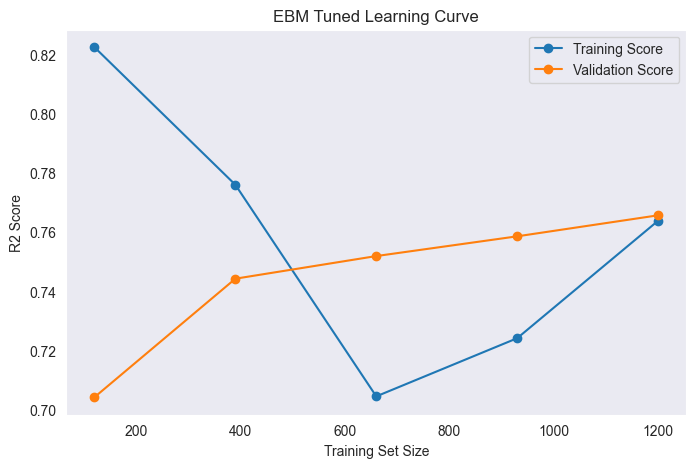

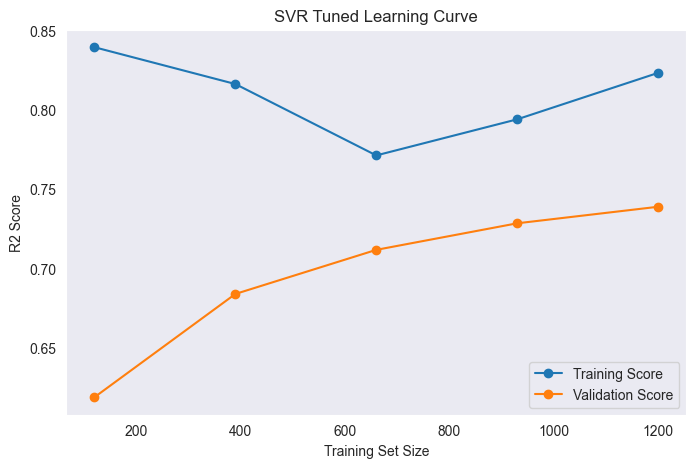

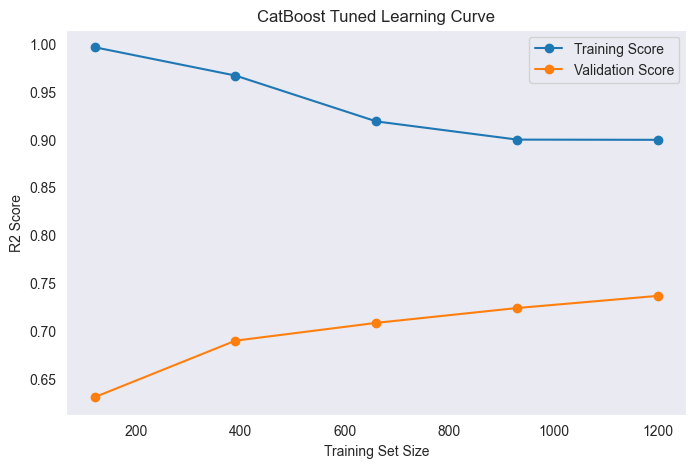

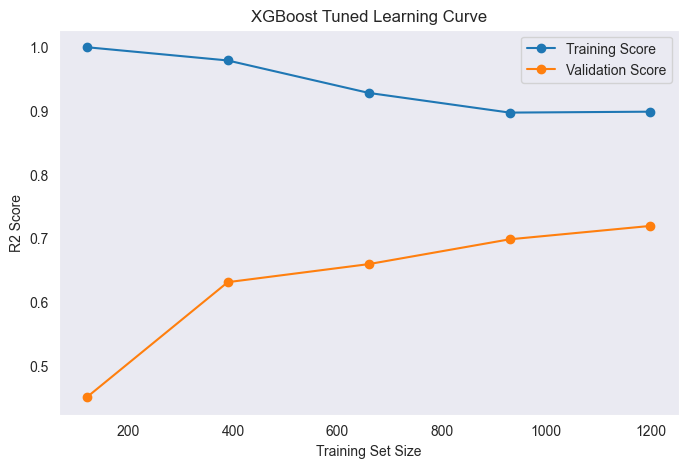

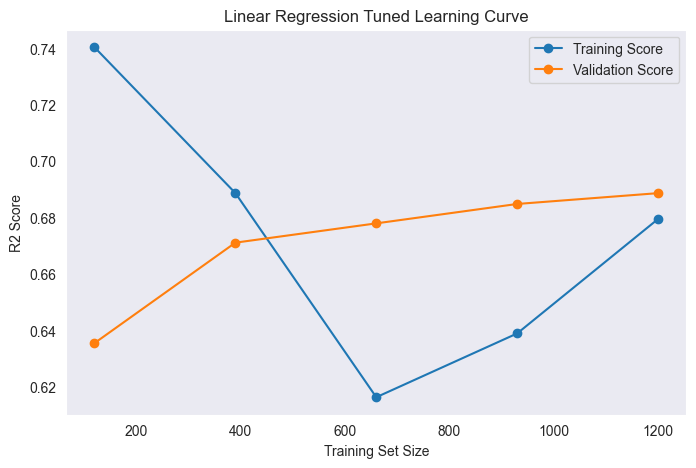

In [133]:
plot_learning_curve(best_ebm, "EBM Tuned Learning Curve", X_train, y_train)

plot_learning_curve(best_svr, "SVR Tuned Learning Curve", X_train_scaled, y_train)

plot_learning_curve(best_cat, "CatBoost Tuned Learning Curve", X_train, y_train)

plot_learning_curve(best_xgb, "XGBoost Tuned Learning Curve", X_train, y_train)

plot_learning_curve(best_linear, "Linear Regression Tuned Learning Curve", X_train_scaled, y_train)

## Concluzii 4.5 – Curbele de invatare

In aceasta etapa au fost analizate curbele de invatare pentru cele 5 modele optimizate, urmarind diferenta dintre scorurile de antrenare si validare pentru a identifica overfitting, underfitting si capacitatea de generalizare.

### EBM Tuned
EBM prezinta cele mai echilibrate curbe, cu diferente mici intre training si validation, ceea ce indica o generalizare buna si un risc redus de overfitting.

### SVR Tuned
SVR are un comportament relativ stabil, cu un gap moderat intre train si validation, oferind un compromis bun intre performanta si stabilitate.

### CatBoost Tuned
CatBoost obtine performante ridicate, dar diferenta mare dintre scorul de training si cel de validation indica overfitting moderat.

### XGBoost Tuned
XGBoost prezinta cel mai puternic overfitting, avand scoruri foarte mari pe training, dar diferente semnificative fata de validation.

### Linear Regression Tuned
Linear Regression are curbe apropiate si stabile, dar performanta generala este mai redusa, sugerand o tendinta de underfitting.

### Concluzie finala
Analiza arata ca:

- EBM este cel mai echilibrat model;
- SVR ofera stabilitate buna;
- CatBoost si XGBoost au performanta ridicata, dar risc crescut de overfitting;
- Linear Regression este stabil, dar limitat ca performanta.

Prin urmare, EBM reprezinta cea mai buna alegere pentru echilibru intre performanta si generalizare, in timp ce XGBoost si CatBoost necesita atentie suplimentara pentru controlul overfitting-ului.

# 4.6 Explicabilitatea si analiza SHAP

In aceasta etapa sunt analizate primele 3 modele optimizate utilizand SHAP (SHapley Additive exPlanations), pentru a interpreta modul in care caracteristicile influenteaza predictiile realizate.

Scopul este explicarea comportamentului celor mai performante modele, atat la nivel global, cat si local, pentru a intelege de ce un anumit scor este prezis.

## Modelele selectate pentru analiza:

- EBM Tuned
- SVR Tuned
- CatBoost Tuned

## Ce se urmareste:

### Explicatie globala:
Pentru fiecare model se analizeaza importanta caracteristicilor folosind:

- SHAP Summary Plot
- SHAP Bar Plot

Aceste grafice evidentiaza cele mai importante variabile implicate in procesul de predictie.

### Explicatie locala:
Pentru predictii individuale se utilizeaza:

- SHAP Waterfall Plot
- SHAP Force Plot

Acestea arata cum fiecare caracteristica contribuie pozitiv sau negativ la rezultatul final.

### Analiza caracteristicilor relevante:
Se realizeaza SHAP Scatter Plot pentru caracteristicile cele mai importante, pentru a observa modul in care valorile acestora influenteaza predictia.

## Obiective principale:

- Identificarea celor mai importante caracteristici
- Intelegerea directiei influentei fiecarei variabile
- Explicarea predictiilor individuale
- Verificarea coerentei modelelor cu problema analizata

## Importanta etapei:

Prin SHAP se poate demonstra:

- ce variabile influenteaza cel mai mult rezultatul;
- cum influenteaza acestea predictia;
- daca modelul ia decizii logice si relevante.

Astfel, analiza SHAP completeaza evaluarea performantei prin oferirea unei perspective clare asupra modului in care modelele perfectionate iau decizii.

In [134]:
import warnings
warnings.filterwarnings("ignore")

import shap
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

shap.initjs()

In [135]:
top_models_shap = {
    "EBM": best_ebm,
    "SVR": best_svr,
    "CatBoost": best_cat
}

In [136]:
X_shap = X_test.sample(min(30, len(X_test)), random_state=42)
X_shap_scaled = scaler.transform(X_shap)

In [137]:
def shap_analysis_regression(model, X_sample, model_name):

    print(f"\n========== SHAP Analysis: {model_name} ==========")

    explainer = shap.Explainer(model.predict, X_sample)
    shap_values = explainer(X_sample)

    print("\n1. Summary plot")
    shap.summary_plot(shap_values, X_sample)

    print("\n2. Bar plot")
    shap.plots.bar(shap_values)

    print("\n3. Waterfall plot pentru prima predictie")
    shap.plots.waterfall(shap_values[0])

    print("\n4. Force plot pentru prima predictie")
    display(shap.plots.force(shap_values[0]))

    mean_importance = np.abs(shap_values.values).mean(axis=0)
    top_3_idx = np.argsort(mean_importance)[-3:][::-1]

    top_features = []

    print("\nCele mai importante 3 caracteristici:")
    for idx in top_3_idx:
        feature_name = X_sample.columns[idx]
        top_features.append(feature_name)
        print(f"- {feature_name}: {mean_importance[idx]:.4f}")

    print("\n5. Scatter plots pentru cele mai importante 3 caracteristici")
    for feature_name in top_features:
        print(f"\nScatter plot pentru: {feature_name}")
        shap.plots.scatter(shap_values[:, feature_name])

    return shap_values, top_features


========== SHAP Analysis: EBM ==========

1. Summary plot


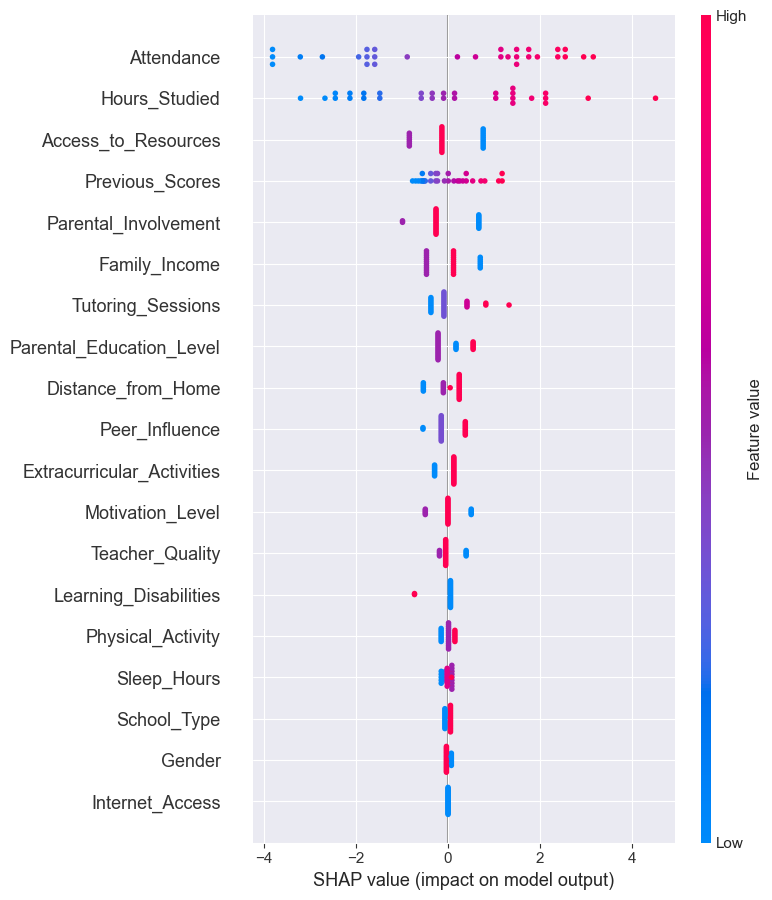


2. Bar plot


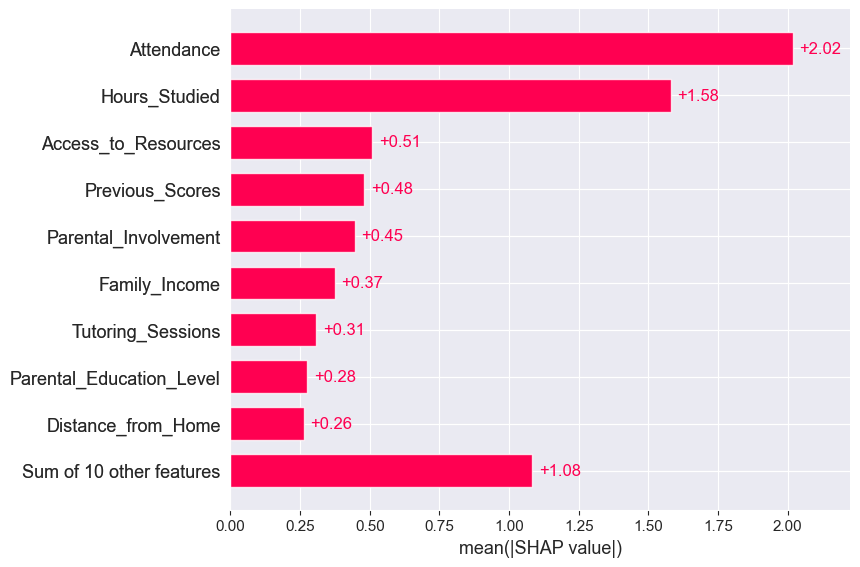


3. Waterfall plot pentru prima predictie


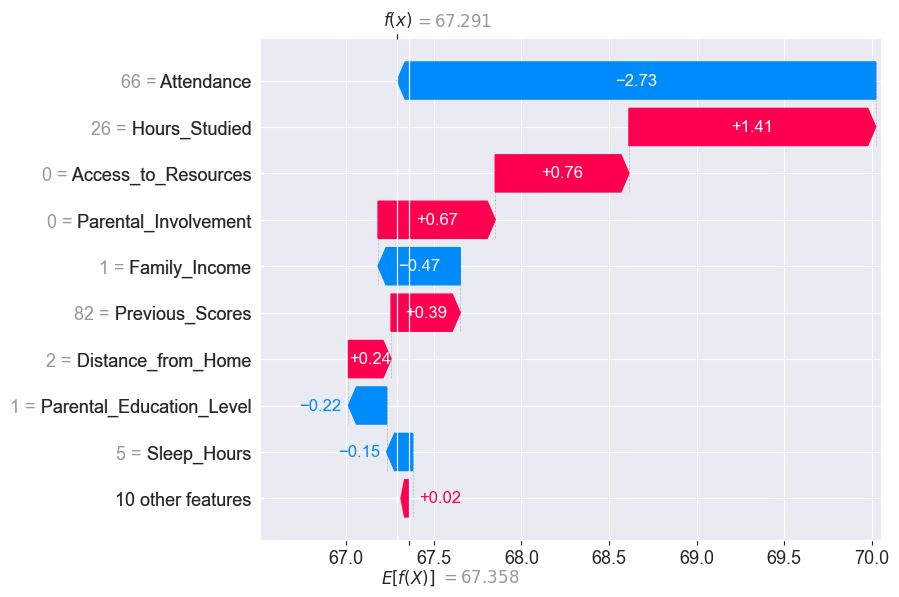


4. Force plot pentru prima predictie



Cele mai importante 3 caracteristici:
- Attendance: 2.0182
- Hours_Studied: 1.5809
- Access_to_Resources: 0.5088

5. Scatter plots pentru cele mai importante 3 caracteristici

Scatter plot pentru: Attendance


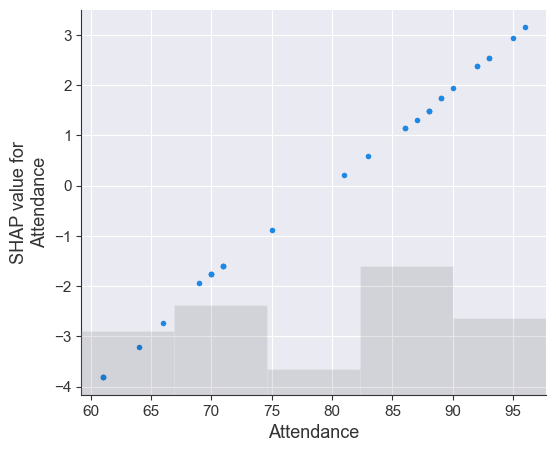


Scatter plot pentru: Hours_Studied


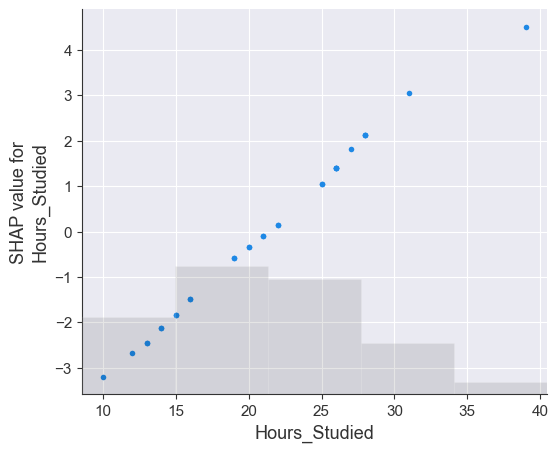


Scatter plot pentru: Access_to_Resources


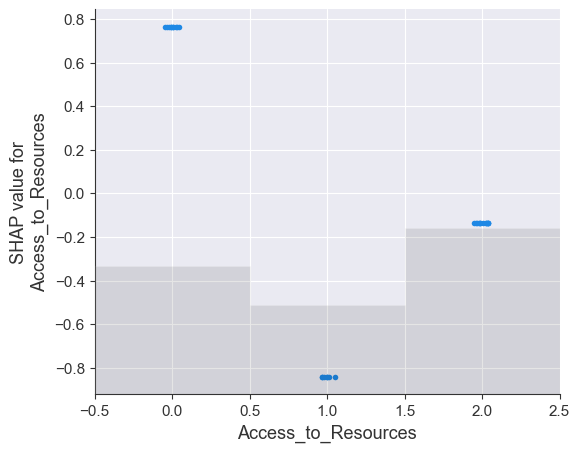

In [138]:
shap_values_ebm, top_features_ebm = shap_analysis_regression(
    best_ebm,
    X_shap,
    "EBM"
)


========== SHAP Analysis: SVR ==========


PermutationExplainer explainer: 31it [00:40,  1.95s/it]                        



1. Summary plot


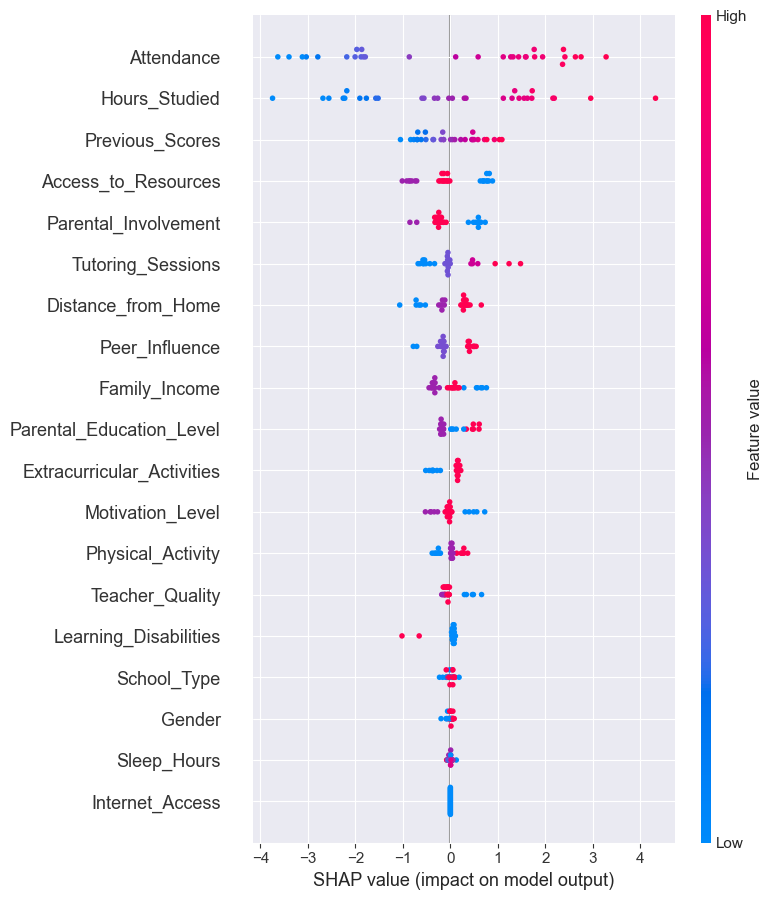


2. Bar plot


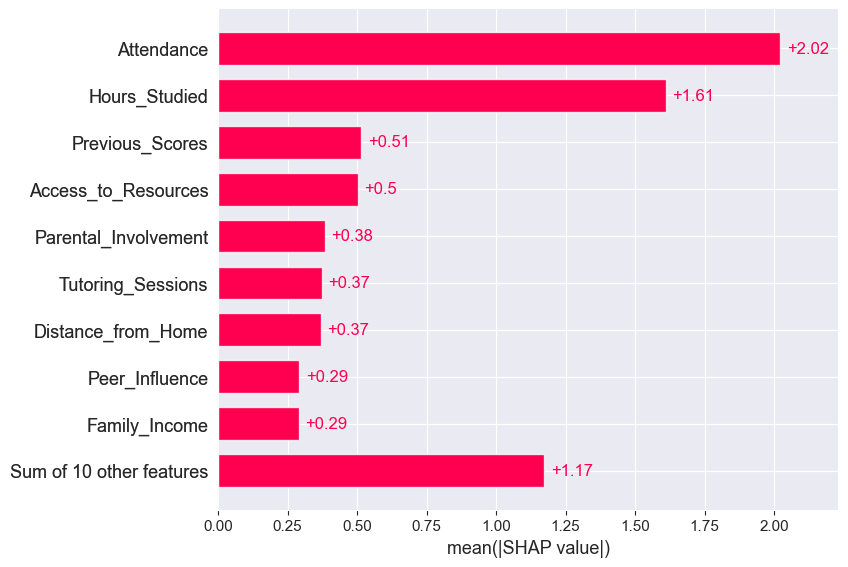


3. Waterfall plot pentru prima predictie


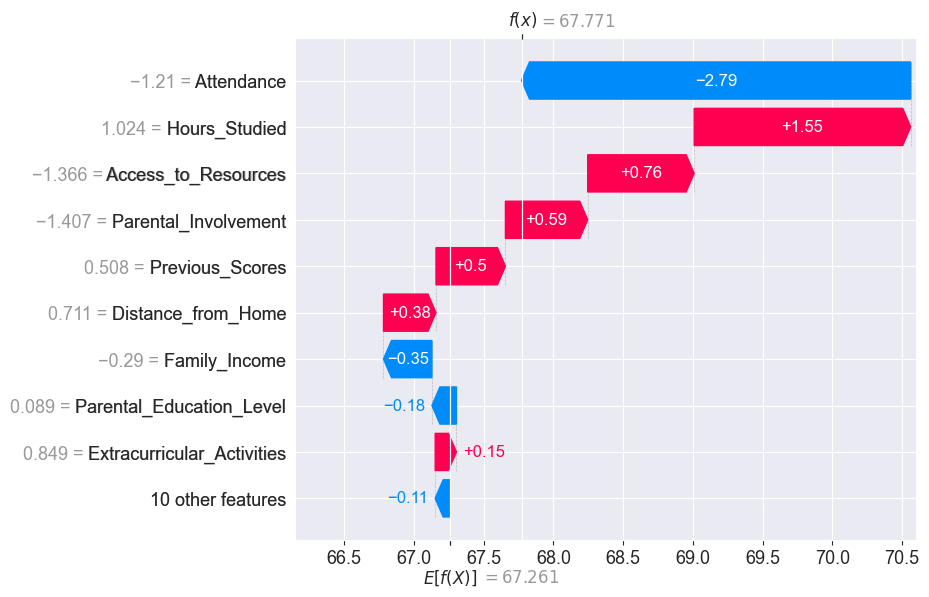


4. Force plot pentru prima predictie



Cele mai importante 3 caracteristici:
- Attendance: 2.0228
- Hours_Studied: 1.6107
- Previous_Scores: 0.5146

5. Scatter plots pentru cele mai importante 3 caracteristici

Scatter plot pentru: Attendance


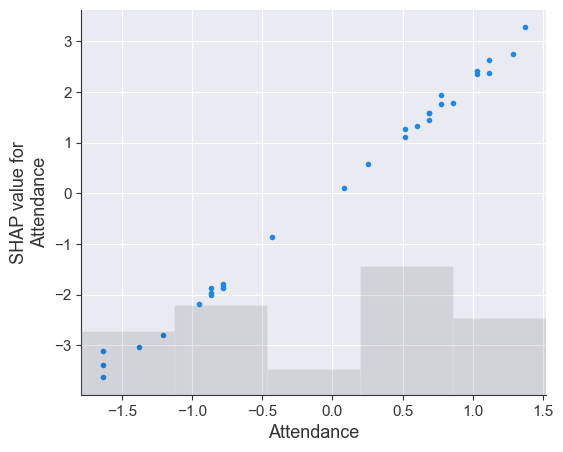


Scatter plot pentru: Hours_Studied


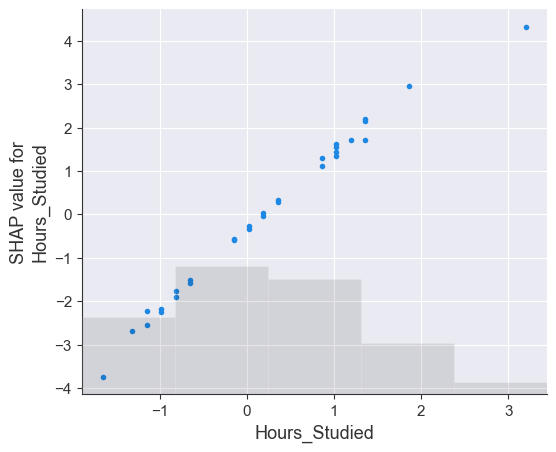


Scatter plot pentru: Previous_Scores


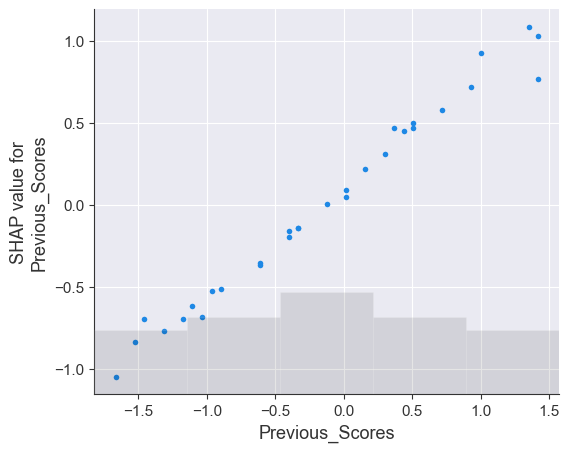

In [140]:
X_shap_scaled_df = pd.DataFrame(X_shap_scaled, columns=X_test.columns)

shap_values_svr, top_features_svr = shap_analysis_regression(
    best_svr,
    X_shap_scaled_df,
    "SVR"
)


========== SHAP Analysis: CatBoost ==========

1. Summary plot


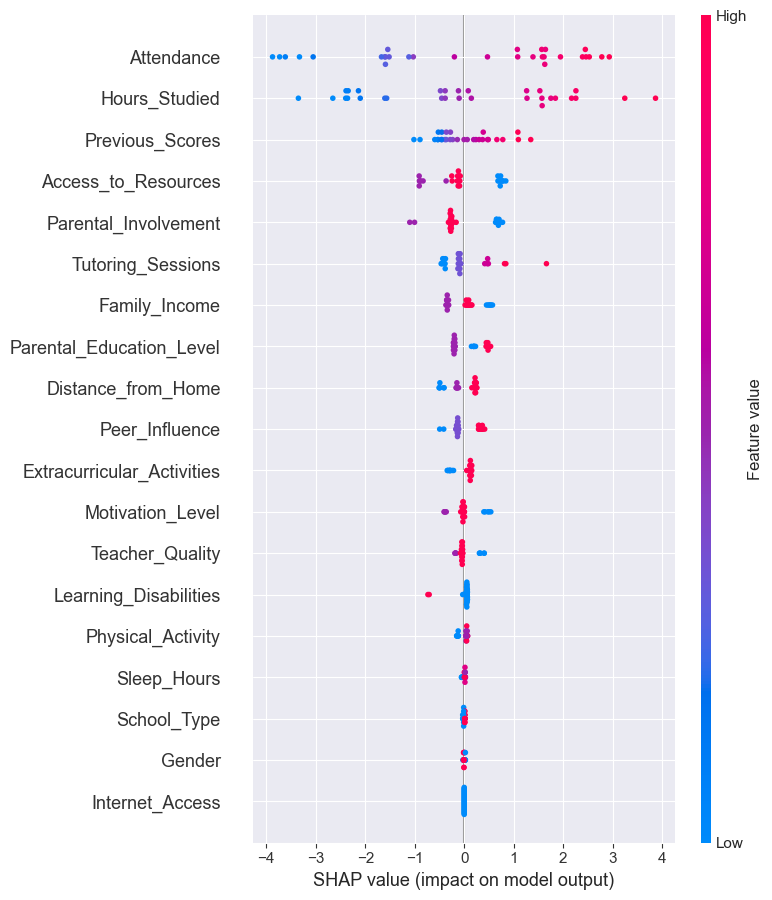


2. Bar plot


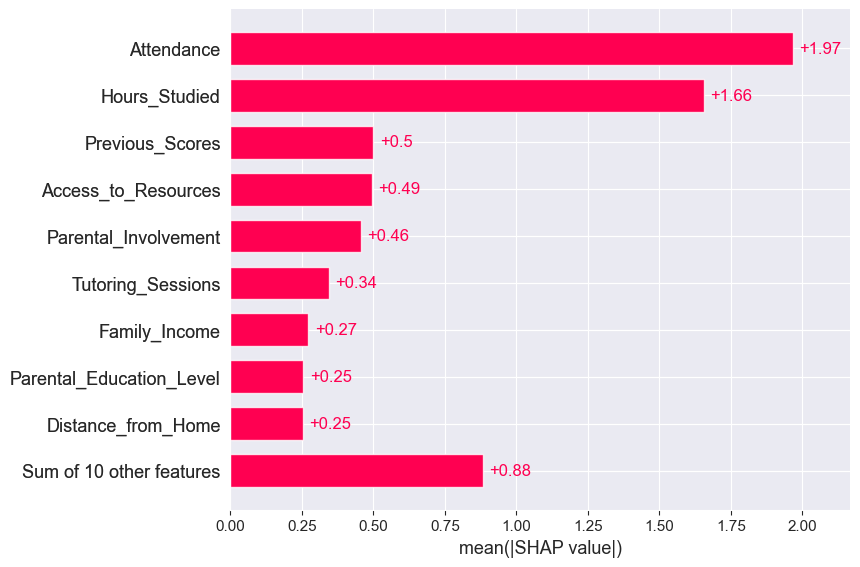


3. Waterfall plot pentru prima predictie


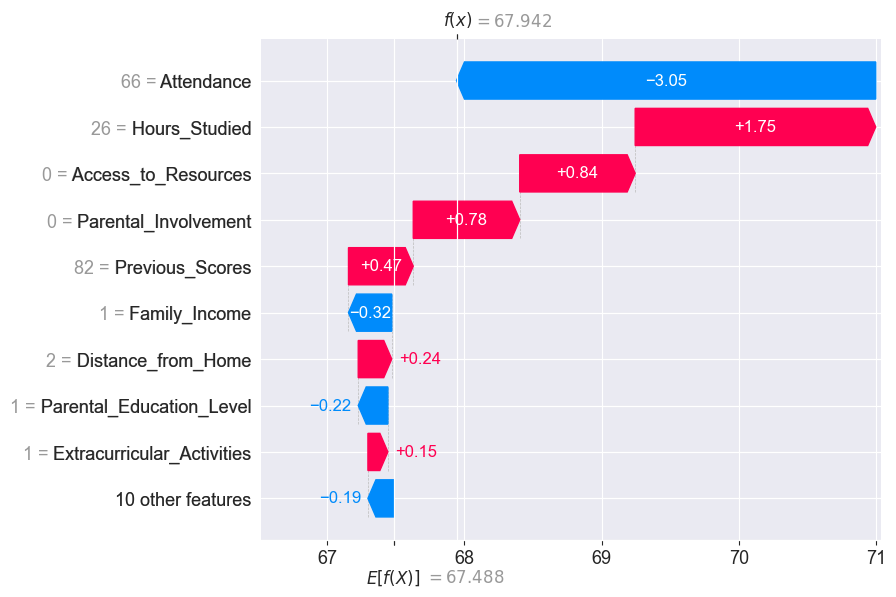


4. Force plot pentru prima predictie



Cele mai importante 3 caracteristici:
- Attendance: 1.9670
- Hours_Studied: 1.6551
- Previous_Scores: 0.4993

5. Scatter plots pentru cele mai importante 3 caracteristici

Scatter plot pentru: Attendance


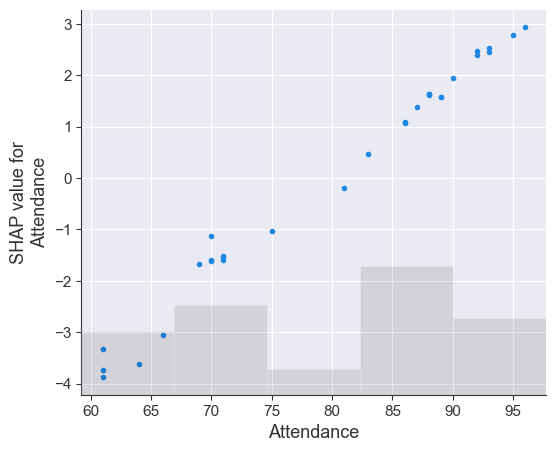


Scatter plot pentru: Hours_Studied


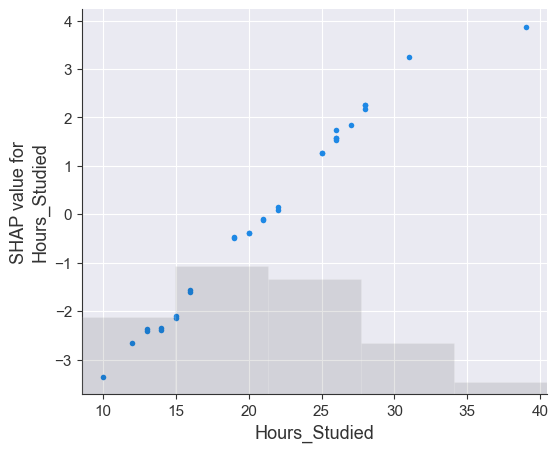


Scatter plot pentru: Previous_Scores


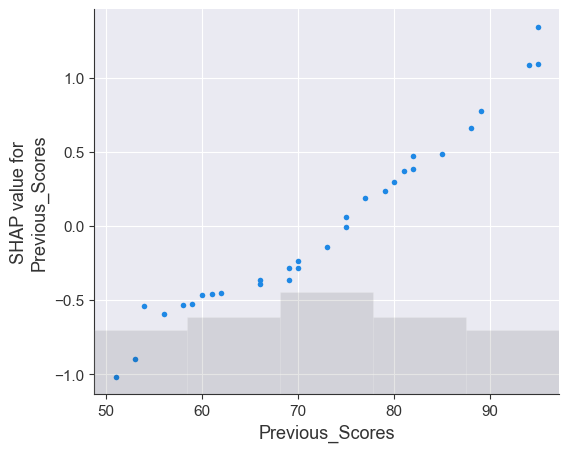

In [141]:
shap_values_cat, top_features_cat = shap_analysis_regression(
    best_cat,
    X_shap,
    "CatBoost"
)

In [142]:
all_shap_results = {
    "EBM": shap_values_ebm,
    "SVR": shap_values_svr,
    "CatBoost": shap_values_cat
}

all_top_features = {
    "EBM": top_features_ebm,
    "SVR": top_features_svr,
    "CatBoost": top_features_cat
}

In [143]:
for model_name, features in all_top_features.items():
    print(f"\n{model_name}")
    print("Top 3 caracteristici importante:")
    for feature in features:
        print(f"- {feature}")


EBM
Top 3 caracteristici importante:
- Attendance
- Hours_Studied
- Access_to_Resources

SVR
Top 3 caracteristici importante:
- Attendance
- Hours_Studied
- Previous_Scores

CatBoost
Top 3 caracteristici importante:
- Attendance
- Hours_Studied
- Previous_Scores


## 4.6 Explicabilitatea si analiza SHAP – Regression

Pentru interpretarea modelelor perfectionate de regresie au fost analizate **EBM**, **SVR** si **CatBoost**, folosind grafice SHAP globale si locale.

Au fost utilizate:
- **Summary plot** si **bar plot** pentru analiza globala a importantei caracteristicilor;
- **Waterfall plot** si **force plot** pentru analiza locala a unei predictii individuale;
- **Scatter plot** pentru observarea modului in care valorile caracteristicilor influenteaza scorul prezis.

### Analiza globala

Din summary plot si bar plot se observa ca cele mai importante caracteristici sunt:

- **Attendance**
- **Hours_Studied**
- **Previous_Scores**
- **Access_to_Resources**

In toate modelele, **Attendance** are cea mai mare influenta asupra predictiei. Valorile mai mari pentru Attendance tind sa creasca scorul prezis, iar valorile mai mici tind sa il scada.

**Hours_Studied** este al doilea factor important. Studentii care studiaza mai multe ore tind sa aiba un scor prezis mai mare.

**Previous_Scores** este important mai ales pentru SVR si CatBoost, ceea ce arata ca rezultatele anterioare influenteaza predictia scorului final.

### Analiza locala

Waterfall plot si force plot arata cum fiecare caracteristica influenteaza o predictie concreta.

Pentru exemplul analizat, o valoare scazuta pentru **Attendance** a redus semnificativ scorul prezis. In schimb, **Hours_Studied** si **Access_to_Resources** au avut contributii pozitive si au crescut predictia.

Acest lucru arata ca modelul nu face predictia doar pe baza unei singure variabile, ci combina mai multi factori.

### Analiza scatter plot

Scatter plot-urile confirma relatiile observate:

- valori mari pentru **Attendance** duc in general la valori SHAP pozitive;
- valori mari pentru **Hours_Studied** cresc predictia;
- valori mari pentru **Previous_Scores** contribuie pozitiv la scor;
- valori scazute ale acestor caracteristici tind sa impinga predictia in jos.

### Concluzii finale

Analiza SHAP arata ca modelele perfectionate sunt coerente si interpretabile.

Cele mai importante caracteristici in procesul de predictie sunt:
- **Attendance**
- **Hours_Studied**
- **Previous_Scores**

Rezultatele sunt logice pentru problema analizata: studentii cu prezenta mai buna, mai multe ore de studiu si rezultate anterioare mai bune tind sa obtina scoruri finale mai mari.

Astfel, SHAP confirma ca modelele nu iau decizii aleatorii, ci se bazeaza pe factori educationali relevanti.

In [144]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

joblib.dump(best_ebm, "saved_models/regression_ebm.pkl")
joblib.dump(best_svr, "saved_models/regression_svr.pkl")
joblib.dump(best_cat, "saved_models/regression_catboost.pkl")
joblib.dump(best_xgb, "saved_models/regression_xgboost.pkl")
joblib.dump(best_linear, "saved_models/regression_linear.pkl")

joblib.dump(scaler, "saved_models/regression_scaler.pkl")

['saved_models/regression_scaler.pkl']

In [147]:
joblib.dump(X.columns.tolist(), "saved_models/classification_columns.pkl")

['saved_models/classification_columns.pkl']